<img src="https://github.com/ArchiColab/sitex/blob/main/images/banner.png?raw=1" width="1000"/>

# Hex Integration: All Indicators of the Ward in One Table

**The question:** which parts of the ward are hot, and have no public green within a short walk?
You can feel the answer at the end of a hot morning on foot, but you cannot see it in any one
of the maps from the earlier notebooks. Each notebook answers one question. This one puts the
answers side by side, one row per hexagon, so you can pick the places worth walking to first.
The objective is to learn how the results of different notebooks are joined into one database,
how to read the files they are saved in, and how to screen the ward for field-trip hot spots.

Every analysis notebook ended with a section **Export for interpretation**. It saved its
results per hexagon of one shared grid (`hex_grid_{slug}.gpkg`, built in
`00-Data-Acquisition.ipynb`), plus a legend that explains every column. This notebook reads
those files, stores them in one DuckDB database file, and asks it questions with SQL.

The numbers are **per hexagon, not per resident**. A hexagon is about 0.1 km², roughly 330 m across.

**Library:** [`sitex`](https://github.com/ArchiColab/sitex)

**Requires (run first):** `00-Data-Acquisition.ipynb` (Section 3b, the hex grid) and the export
section of each notebook you want in the table. A table that is missing is skipped, so you can
build the database with what you have:

| Table | Notebook | Section |
|---|---|---|
| `buildings`, `hex_morphology` | `01-ARCH-Building_Morphology.ipynb` | 10 |
| `hex_uhi` | `02-ENV-UHI_Analysis.ipynb` | 8 |
| `hex_amenities` | `03-NA03-Amenity_Isochrones.ipynb` | 7 |
| `hex_spacesyntax` | `03-NA01-SpaceSyntax.ipynb` | 12 |
| `hex_green` | `03-NA06-Green_Accessibility.ipynb` | 9 |

**Output (`data/gdf/`):** `{slug}_hex.duckdb`, the database, and `{slug}_hex_grid.parquet`, the
hexagons as a GeoParquet file.

**What you edit:** `SLUG` in Section 3, and the screening choices in Section 6.

---
## Coordinate systems (CRS)

- **All hexagon and building files are in the site's UTM zone** (metres; global UTM, for
  example EPSG:32649 for Pleiku), like every other analysis layer in the workshop.
- This notebook does not reproject anything. The coordinate system is saved inside the
  GeoParquet files, so it travels with the data.

---
## 1. Install & import

DuckDB and `pyarrow` (which reads and writes Parquet files) come with the `hex` extra of `sitex`,
installed by the first line of the next cell. On your own computer, install them once with
`pip install "sitex[hex] @ git+https://github.com/ArchiColab/sitex.git"`.

In [1]:
#@title <font color=#1B7192> Configuration </font>  { display-mode: "form" }

# One-time setup, if `duckdb` isn't already installed in this kernel:
# %pip install "sitex[hex] @ git+https://github.com/ArchiColab/sitex.git"

import sys
import time
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
print("Running in:", "Google Colab" if IN_COLAB else "Local environment")

if IN_COLAB:
    %pip install "sitex[hex] @ git+https://github.com/ArchiColab/sitex.git"

    from google.colab import drive
    drive.mount("/content/gdrive")

    DATA_DIR = Path("/content/gdrive/MyDrive/Colab_Outputs")
    OUTPUT_DIR = Path("/content/gdrive/MyDrive/SiteX_Outputs")
else:
    DATA_DIR = Path("..") / "data"
    OUTPUT_DIR = Path("..") / "outputs"

DATA_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

import duckdb
import geopandas as gpd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display

print("DuckDB", duckdb.__version__)

Running in: Local environment
DuckDB 1.5.2


---
## 2. The files you are about to read

The earlier notebooks saved their results in three kinds of file. You will meet all three here.

| File | What it is | Example |
|---|---|---|
| **Parquet** (`.parquet`) | A table saved by column instead of by row. It is small, fast to read, and remembers the type of every column (whole number, decimal, text). A CSV remembers none of this. | `{slug}_hex_uhi.parquet`: one row per hexagon |
| **GeoParquet** (`.parquet`) | A Parquet file with one extra column, `geometry`, that holds shapes in a standard way, and the coordinate system written inside the file. | `{slug}_buildings.parquet`: one row per building footprint |
| **Legend** (`.csv`) | A small text table that explains the columns of a result file. Open it in Excel or any text editor. | `{slug}_hex_uhi_legend.csv` |

**Parquet or GeoParquet?** A file is GeoParquet when it has a `geometry` column. The hexagon
result tables (`hex_uhi`, `hex_green`, ...) have none, to keep them small. They find their
hexagon through the key `h3_id`, the name of the hexagon in the H3 grid. The hexagon outlines
are in `{slug}_hex_grid.parquet`, which this notebook writes from `hex_grid_{slug}.gpkg`. To
see a GeoParquet file as a map in Python, read it with `geopandas.read_parquet`. For QGIS, use
the GeoPackage files of the same notebooks.

**The legend.** A number without its unit and its source is easy to misread. Every export
section therefore saved a legend with one row per column:

| Legend column | Answers |
|---|---|
| `table`, `column` | Which table and which column is this row about? |
| `unit` | In what unit is the number (°C, m, minutes, count)? |
| `definition` | What exactly was calculated? |
| `source` | Which data and which notebook section did it come from? |
| `limits` | **What can the number not tell you?** |

Read the `limits` before you read a map. This notebook joins all the legends into one table.

**DuckDB** is a database in a single file, with no server to install. You ask it questions in
**SQL**, for example "all hexagons hotter than the 75th percentile and with no public green",
and it joins the tables through `h3_id` in one line. The database file is only a copy of the
Parquet files: you can delete it and build it again at any time.

---
## 3. Find the tables

Set `SLUG` to the same value as in the other notebooks. The cell lists which result files it
finds. A missing file is not an error: the table is skipped, and you can build the database
again after you run the missing notebook.

In [2]:
#@title <font color=#1B7192> Click to run </font>  { display-mode: "form" }

_t0 = time.time()
print("### 3. Find the tables ###", flush=True)

SLUG = "pleiku" #@param {type:"string"}
#@markdown <font color=#1B7192> Same SLUG as in the other notebooks. </font>

GDF_DIR = DATA_DIR / "gdf"
GDF_DIR.mkdir(parents=True, exist_ok=True)

HEX_GRID_GPKG = DATA_DIR / f"hex_grid_{SLUG}.gpkg"
if not HEX_GRID_GPKG.exists():
    raise FileNotFoundError(f"{HEX_GRID_GPKG} not found -- run 00-Data-Acquisition.ipynb Section 3b first.")

FILES = {   # table name in the database: file
    "hex_grid": GDF_DIR / f"{SLUG}_hex_grid.parquet",        # written in Section 4
    "buildings": GDF_DIR / f"{SLUG}_buildings.parquet",
    "hex_morphology": GDF_DIR / f"{SLUG}_hex_morphology.parquet",
    "hex_uhi": GDF_DIR / f"{SLUG}_hex_uhi.parquet",
    "hex_amenities": GDF_DIR / f"{SLUG}_hex_amenities.parquet",
    "hex_spacesyntax": GDF_DIR / f"{SLUG}_hex_spacesyntax.parquet",
    "hex_green": GDF_DIR / f"{SLUG}_hex_green.parquet",
}
DB_PATH = GDF_DIR / f"{SLUG}_hex.duckdb"

print(f"Hex grid : {HEX_GRID_GPKG.name}")
for name, path in FILES.items():
    if name != "hex_grid":
        print(f"  {name:16s} {'found' if path.exists() else 'MISSING'}  {path.name}")

print(f"--- 3. done in {time.time() - _t0:.2f}s ---\n")

### 3. Find the tables ###
Hex grid : hex_grid_pleiku.gpkg
  buildings        found  pleiku_buildings.parquet
  hex_morphology   found  pleiku_hex_morphology.parquet
  hex_uhi          found  pleiku_hex_uhi.parquet
  hex_amenities    found  pleiku_hex_amenities.parquet
  hex_spacesyntax  found  pleiku_hex_spacesyntax.parquet
  hex_green        found  pleiku_hex_green.parquet
--- 3. done in 0.00s ---



---
## 4. Build the database

Four steps, all in the next cell:

1. The hexagon outlines are saved as GeoParquet, `{slug}_hex_grid.parquet`.
2. Each Parquet file becomes one **table** in the database, with the same name as in the
   table above. `buildings` is the GeoParquet file of footprints.
3. All legend files are joined into one table, `legend`.
4. A **view** called `hex_all` joins every hexagon table to the grid through `h3_id`: one row
   per hexagon, one column per indicator. A column that exists in two tables (for example the
   distance to the nearest street, `snap_dist_m`, in the amenity and green tables) gets the
   table name in front, so the two stay apart.

In [3]:
#@title <font color=#1B7192> Click to run </font>  { display-mode: "form" }

_t0 = time.time()
print("### 4. Build the database ###", flush=True)

# 1. hexagons -> GeoParquet
hexes = gpd.read_file(HEX_GRID_GPKG, layer="hex")
hexes.to_parquet(FILES["hex_grid"])

# 2. one table per file
DB_PATH.unlink(missing_ok=True)
con = duckdb.connect(str(DB_PATH))
loaded = []
for name, path in FILES.items():
    if not path.exists():
        print(f"  [skipped] {name}: {path.name} not found -- run its notebook first")
        continue
    con.execute(f"CREATE TABLE {name} AS SELECT * FROM read_parquet('{path.as_posix()}')")
    n_rows = con.sql(f"SELECT count(*) FROM {name}").fetchone()[0]
    print(f"  {name:16s} {n_rows:>7,} rows   <- {path.name}")
    loaded.append(name)

# 3. one legend table
con.execute("""CREATE TABLE legend (table_name VARCHAR, column_name VARCHAR, unit VARCHAR,
               definition VARCHAR, source VARCHAR, limits VARCHAR)""")
epsg = hexes.crs.to_epsg()
grid_legend = pd.DataFrame([
    ("hex_grid", "h3_id", "-", "Key of the hexagon (H3 cell)", f"hex_grid_{SLUG}.gpkg", "-"),
    ("hex_grid", "lat", "degrees", "Latitude of the hexagon centre (EPSG:4326)", f"hex_grid_{SLUG}.gpkg", "-"),
    ("hex_grid", "lon", "degrees", "Longitude of the hexagon centre (EPSG:4326)", f"hex_grid_{SLUG}.gpkg", "-"),
    ("hex_grid", "area_m2", "m2", f"Area of the hexagon (EPSG:{epsg})", f"hex_grid_{SLUG}.gpkg", "-"),
    ("hex_grid", "geometry", "polygon", f"Outline of the hexagon (EPSG:{epsg})", f"hex_grid_{SLUG}.gpkg", "-"),
], columns=["table_name", "column_name", "unit", "definition", "source", "limits"])
con.register("grid_legend", grid_legend)
con.execute("INSERT INTO legend SELECT * FROM grid_legend")
for legend_file in sorted(GDF_DIR.glob(f"{SLUG}_hex_*_legend.csv")):
    con.execute(f"""INSERT INTO legend SELECT "table", "column", unit, definition, source, limits
                    FROM read_csv('{legend_file.as_posix()}', header = true, all_varchar = true)""")
    print(f"  legend           <- {legend_file.name}")

# 4. the view: one row per hexagon
hex_tables = [t for t in loaded if t.startswith("hex_") and t != "hex_grid"]
columns = {t: [r[0] for r in con.sql(f"DESCRIBE {t}").fetchall() if r[0] != "h3_id"] for t in hex_tables}
all_names = [c for cols in columns.values() for c in cols]
select = ["g.h3_id", "g.lat", "g.lon", "g.area_m2"]
for t, cols in columns.items():
    for c in cols:
        out = f"{t.removeprefix('hex_')}_{c}" if all_names.count(c) > 1 else c
        select.append(f"{t}.{c} AS {out}")
joins = " ".join(f"LEFT JOIN {t} USING (h3_id)" for t in hex_tables)
con.execute(f"CREATE VIEW hex_all AS SELECT {', '.join(select)} FROM hex_grid g {joins}")
n_cols = len(con.sql("DESCRIBE hex_all").fetchall())
print(f"  hex_all (view)   {n_cols} columns, one row per hexagon")

print(f"\nSaved -> {DB_PATH}")
print(f"--- 4. done in {time.time() - _t0:.2f}s ---\n")

### 4. Build the database ###
  hex_grid             217 rows   <- pleiku_hex_grid.parquet
  buildings         21,389 rows   <- pleiku_buildings.parquet
  hex_morphology       217 rows   <- pleiku_hex_morphology.parquet
  hex_uhi              217 rows   <- pleiku_hex_uhi.parquet
  hex_amenities        217 rows   <- pleiku_hex_amenities.parquet
  hex_spacesyntax      217 rows   <- pleiku_hex_spacesyntax.parquet
  hex_green            217 rows   <- pleiku_hex_green.parquet
  legend           <- pleiku_hex_amenities_legend.csv
  legend           <- pleiku_hex_green_legend.csv
  legend           <- pleiku_hex_morphology_legend.csv
  legend           <- pleiku_hex_spacesyntax_legend.csv
  legend           <- pleiku_hex_uhi_legend.csv
  hex_all (view)   33 columns, one row per hexagon

Saved -> ..\data\gdf\pleiku_hex.duckdb
--- 4. done in 0.33s ---



---
## 5. Read the legend, then check the numbers

The `legend` table is now an ordinary table in the database. Ask it about one result table,
and always read the last column, `limits`. Set `LEGEND_TABLE` to any table name from the list
printed above, for example `hex_green`.

The cell also checks the other way round: every column of every table should have a row in the
legend. A column without a row is a number nobody has explained yet.

In [4]:
#@title <font color=#1B7192> Click to run </font>  { display-mode: "form" }

_t0 = time.time()
print("### 5. Read the legend ###", flush=True)

LEGEND_TABLE = "hex_uhi" #@param {type:"string"}

pd.set_option("display.max_colwidth", 120)
display(con.sql(f"""
    SELECT column_name, unit, definition, limits
    FROM legend WHERE table_name = '{LEGEND_TABLE}'
""").df())

# every column of every table has a legend row?
in_legend = set(con.sql("SELECT table_name, column_name FROM legend").fetchall())
missing = [(t, r[0]) for t in loaded for r in con.sql(f"DESCRIBE {t}").fetchall() if (t, r[0]) not in in_legend]
print("Columns without a legend row:", missing if missing else "none")

print(f"--- 5. done in {time.time() - _t0:.2f}s ---\n")

### 5. Read the legend ###


,column_name,unit,definition,limits
0,h3_id,-,"Key of the hexagon (H3 cell, resolution 9)",-
1,lst_mean_c,deg C,Mean land surface temperature of the hexagon on 2026-03-28,"Surface, not air temperature. One scene at about 10:00 local time. Measured at 100 m, resampled to 30 m: the hexagon..."
2,hei_mean,0 to 1,"Mean Heat Exposure Index, equal weights (50/50) of normalised LST and vegetation deficit","Screening indicator, not validated. Normalised within this AOI: ranks hexagons here, not comparable with other sites"
3,ndvi_mean,-1 to 1,Mean Landsat NDVI of the hexagon on 2026-03-28,One date: depends on season and rain
4,n_valid_px,pixels,"Cloud-free 30 m pixels in the hexagon, counted by the share of each inside it","Fractional, because edge pixels count in part"
5,valid_frac,0 to 1,Share of the hexagon area with valid Landsat values; the means are empty below 0.5,Clouds and cloud shadows removed with the quality band
6,ndvi_s2_mean,-1 to 1,"Mean Sentinel-2 NDVI of the hexagon, 2025","Different sensor, date and resolution from ndvi_mean"
7,ndbi_s2_mean,-1 to 1,"Mean Sentinel-2 NDBI of the hexagon, 2025: high for built-up surfaces and bare soil",Bare soil also scores high
8,s2_n_valid_px,pixels,"Valid 10 m Sentinel-2 pixels in the hexagon, counted by the share of each inside it","Fractional, because edge pixels count in part"
9,s2_valid_frac,0 to 1,Share of the hexagon area with valid Sentinel-2 values; the means are empty below 0.5,-


Columns without a legend row: none
--- 5. done in 0.03s ---



### Check the numbers

The legend says what a column should mean. The statistics say what is actually in it. For every column
of `hex_all` (one row per hexagon) and of the `buildings` table, the next cell shows how many values
there are, how many are empty, the smallest and largest value, the average and the quartiles, next to
the unit from the legend. It uses DuckDB's `SUMMARIZE`.

**Read the minimum and the maximum against the unit.** This is how the problems of the earlier cycles
were found: a negative ground height in a delta, a temperature that no surface can have, a footprint of
a few square centimetres. Look for:

- a value the unit does not allow (a negative count, a share above 100, a height of 0.01 m);
- a minimum or maximum far away from the quartiles (one extreme value in a column of ordinary ones);
- a column that is empty or has a single value.

The cell lists the last two kinds automatically. The rest is your reading. A strange value is not always an
error, but it needs an explanation before you use the column. The statistics are also saved in the
database as the table `stats`.

In [ ]:
#@title <font color=#1B7192> Click to run </font>  { display-mode: "form" }

_t0 = time.time()
print("### 5b. Check the numbers ###", flush=True)

parts = []
for source, query in (("hex_all", "SELECT * FROM hex_all"),
                      ("buildings", "SELECT * EXCLUDE (geometry) FROM buildings")):
    if source == "buildings" and "buildings" not in loaded:
        continue
    part = con.sql(f"SUMMARIZE {query}").df()
    part.insert(0, "table_name", source)
    parts.append(part)
stats = pd.concat(parts, ignore_index=True)

# unit from the legend (a column that has the table name in front in hex_all is looked up without it)
unit_of = dict(con.sql("SELECT column_name, unit FROM legend").fetchall())
stats["unit"] = [unit_of.get(c) or unit_of.get(c.split("_", 1)[-1], "") for c in stats["column_name"]]
stats = stats[["table_name", "column_name", "unit", "column_type", "count", "null_percentage",
               "min", "max", "avg", "q25", "q50", "q75"]]

con.register("stats_df", stats)
con.execute("CREATE OR REPLACE TABLE stats AS SELECT * FROM stats_df")

shown = stats.copy()
for col in ["min", "max", "avg", "q25", "q50", "q75"]:
    number = pd.to_numeric(shown[col], errors="coerce")
    shown[col] = number.round(2).where(number.notna(), shown[col])
pd.set_option("display.max_rows", 200)
display(shown)

empty = stats[stats["null_percentage"] >= 100]
single = stats[(stats["null_percentage"] < 100) & (stats["min"] == stats["max"])]
print("Columns that are completely empty:", list(empty["column_name"]) or "none")
print("Columns with a single value      :", list(single["column_name"]) or "none")

print(f"--- 5b. done in {time.time() - _t0:.2f}s ---\n")

---
## 6. Screen the hexagons: hot, and no public green nearby

The example question: **where is the surface hottest, and no public green space within the
walking time of the green-access notebook (15 minutes)?** In SQL, in `hex_all`, that is two
conditions:

- `lst_mean_c` is among the hottest `HOT_PERCENT`% hexagons (land surface temperature, from
  `hex_uhi`);
- `access_public_min IS NULL`: the walking time to public green is empty, because no public green
  is reachable within the walking time (from `hex_green`).

The map shows the hexagons that pass both in red. **This is a screening, not a result:** the
percentage is your choice, and a hexagon in red is a place to go and look at, not a verdict.
Change `HOT_PERCENT` (for example to 50 or 90) and run the cell again to see how the picture
depends on it. The same pattern works for any two columns of `hex_all`.

### 6. Screen the hexagons ###
34 of 217 hexagons: hottest 25% and no public green within reach


,h3_id,lst_c,hei,n_buildings,coverage
0,8969368d9b7ffff,49.5,0.66,0,0.00
1,8969368ca7bffff,49.2,0.63,1,0.00
2,8969368c863ffff,48.2,0.64,33,0.39
3,89693616483ffff,47.2,0.58,41,0.06
4,8969368c87bffff,46.7,0.59,38,0.23
5,8969368ca33ffff,46.7,0.59,23,0.10
6,8969368c84fffff,46.4,0.59,30,0.29
7,8969368cab3ffff,45.8,0.56,41,0.26
8,8969368d993ffff,45.6,0.53,52,0.06
9,8969368d933ffff,45.6,0.54,56,0.05


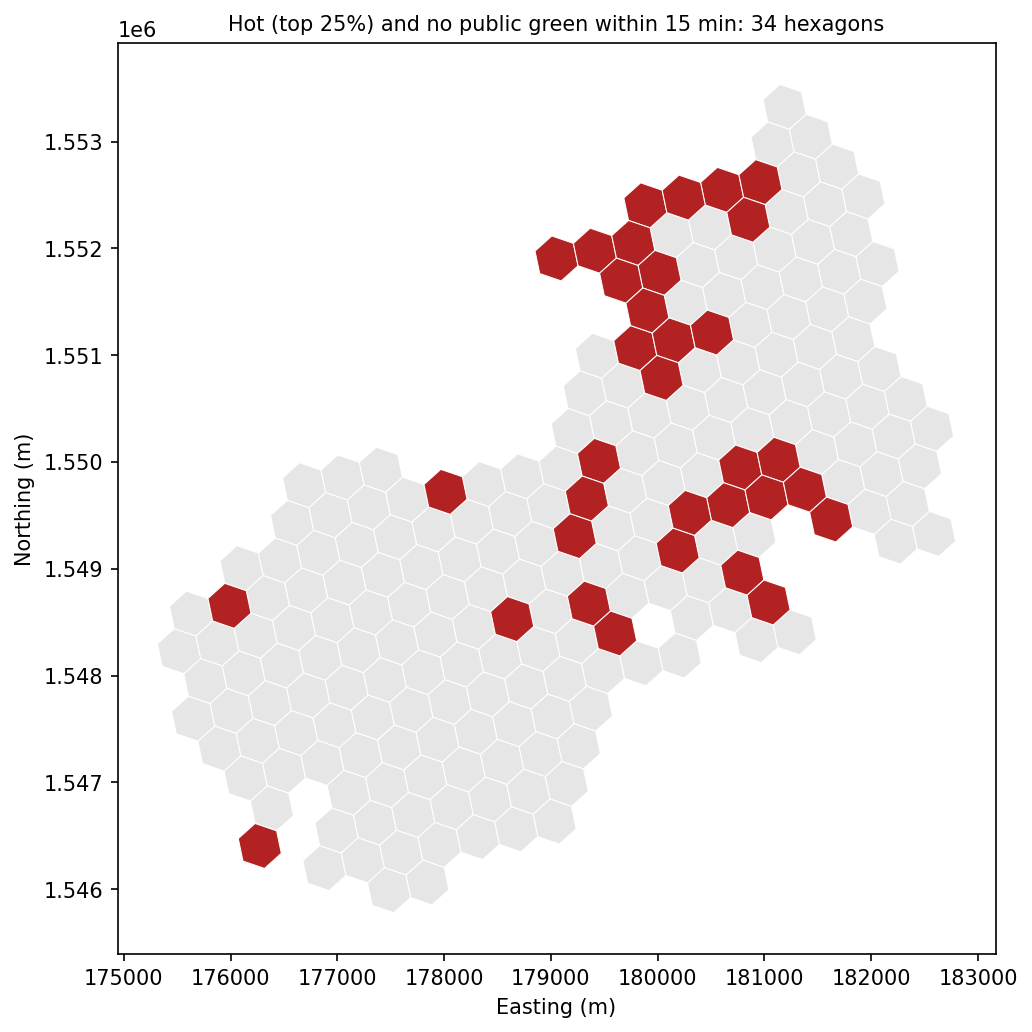

--- 6. done in 0.58s ---



In [ ]:
#@title <font color=#1B7192> Click to run </font>  { display-mode: "form" }

_t0 = time.time()
print("### 6. Screen the hexagons ###", flush=True)

HOT_PERCENT = 75 #@param {type:"slider", min:50, max:95, step:5}
#@markdown <font color=#1B7192> Hexagons in the hottest (100 - this)% by land surface temperature count as hot. </font>

needed = {"hex_uhi", "hex_green", "hex_morphology"}
if not needed <= set(loaded):
    print(f"Missing tables: {sorted(needed - set(loaded))}. Run their notebooks and build the database again (Section 4).")
else:
    selected = con.sql(f"""
        SELECT h3_id,
               round(lst_mean_c, 1)  AS lst_c,
               round(hei_mean, 2)    AS hei,
               n_buildings,
               round(coverage_ratio, 2) AS coverage
        FROM hex_all
        WHERE lst_mean_c >= (SELECT quantile_cont(lst_mean_c, {HOT_PERCENT / 100}) FROM hex_all)
          AND access_public_min IS NULL
        ORDER BY lst_mean_c DESC
    """).df()
    print(f"{len(selected)} of {len(hexes)} hexagons: hottest {100 - HOT_PERCENT}% and no public green within reach")
    display(selected.head(10))

    grid = gpd.read_parquet(FILES["hex_grid"])
    fig, ax = plt.subplots(figsize=(7, 7))
    grid.plot(ax=ax, color="#e6e6e6", edgecolor="white", linewidth=0.5)
    grid[grid["h3_id"].isin(selected["h3_id"])].plot(ax=ax, color="#b22222", edgecolor="white", linewidth=0.5)
    ax.set_title(f"Hot (top {100 - HOT_PERCENT}%) and no public green within 15 min: {len(selected)} hexagons", fontsize=10)
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")
    ax.set_aspect("equal")
    plt.tight_layout()
    screen_png = OUTPUT_DIR / f"{SLUG}_hex_screening.png"
    fig.savefig(screen_png, dpi=150, bbox_inches="tight")
    plt.close(fig)
    display(Image(str(screen_png)))

print(f"--- 6. done in {time.time() - _t0:.2f}s ---\n")

---
## 7. Field check: from the hexagon to the street

A hexagon is about 330 m across: far too big to read a single street, but the right size to
choose where to go. Before the field trip, pick 2-3 hexagons for each row, and read the legend
`limits` of the columns you use.

| Pattern in `hex_all` | What the model predicts | What to check on the ground |
|---|---|---|
| Hot, and no public green within reach (red on the map) | Hot surfaces, and no mapped public place to cool down | Is there shade on the footpath? Where do people go instead: a shop, a café, a covered passage? Is there green that is not mapped as public (`gap_class` = `environment_only` in `hex_green`)? |
| Hot, but public green within reach | The green is near, yet the area is still hot | Can people use the green: shade, benches, an open gate? Or are the surfaces around it the reason for the heat? |
| `height_reliable` is false in `hex_morphology` | Most building heights in the hexagon are filled in by the notebook, not measured | Count the floors of a few buildings and compare with `mean_height` |

Write down what you find for each hexagon in one line: the hexagon's `h3_id`, the pattern, and
what you saw. Your lines are the test of the model.

---
## Notes

- **The numbers are per hexagon, not per resident.** There is no population data: the built
  area of a hexagon (`built_area_m2`, `coverage_ratio`) stands in for density, and every
  hexagon counts the same.
- **Every table comes from its own run.** The land surface temperature is one Landsat scene,
  the buildings come from Overture, the green layers from OpenStreetMap and WorldCover. If you
  re-run a notebook, run its export section again and build the database again (Section 4).
- **The grid is the finest scale of the weakest layer.** Landsat measures temperature at 100 m,
  so a hexagon of about 0.1 km² is as fine as it supports.
- **Empty is not zero.** An empty `access_public_min` means no public green within the walking
  time. An empty mean means the hexagon has no data for it (for example no buildings, or too
  few cloud-free pixels).
- **Flood risk, population and Gehl place themes are not in the grid.** They are not reliable
  enough at this scale, or need a survey on site.
- **The screening percentage is a choice**, not a standard. Show the choice next to the map.

---
## When the model is wrong

Where your notes and the hexagon disagree, write down why. Common reasons:

- **The hexagon mixes places.** A park, a market and a row of houses can share one hexagon, and
  the mean describes none of them.
- **The temperature is a surface at one moment** (about 10:00 on one day), not what people feel
  in the shade.
- **Unmapped public green.** A park nobody mapped in OpenStreetMap counts as missing.
- **The hexagon edge is arbitrary.** A hot place on the edge of a hexagon is counted in the
  hexagon that contains its centre.

Write one sentence per disagreement: *"The model says …, I found …, because …"*.

## Where to go next

| Next step | Open |
|---|---|
| See a layer behind a column in detail, with its own field check | [`02-ENV-UHI_Analysis.ipynb`](02-ENV-UHI_Analysis.ipynb), [`03-NA06-Green_Accessibility.ipynb`](03-NA06-Green_Accessibility.ipynb) |
| Find the busy streets inside a hexagon | [`03-NA01-SpaceSyntax_FieldTripIntro.ipynb`](03-NA01-SpaceSyntax_FieldTripIntro.ipynb) |

**Into the design phase:** the hexagons that stay red under a stricter choice (for example 90%
instead of 75%) are the strongest case for shade, planting or a new public green space. Draw
your proposal in QGIS on the GeoPackage layers of the notebooks.